In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

# --- 1. DATA LOADING AND UNIFICATION ---

def load_and_unify_data(spp_filepath, kinematic_filepath):
    """
    Loads SPP and Kinematic data, aligns them, calculates differences,
    and returns a single unified DataFrame using explicit column names.
    """
    try:
        spp_df = pd.read_csv(spp_filepath)
        kin_df = pd.read_csv(kinematic_filepath)
        print(f"✓ SPP file loaded with {len(spp_df)} rows.")
        print(f"✓ Kinematic file loaded with {len(kin_df)} rows.")
    except Exception as e:
        print(f"✗ Error loading files: {e}")
        return None, None, None, None, None

    spp_df['GPST'] = pd.to_datetime(spp_df['GPST']).dt.floor('S')
    kin_df['GPST'] = pd.to_datetime(kin_df['GPST']).dt.floor('S')

    c = pd.merge(spp_df, kin_df, how='inner', on='GPST')

    unified_df = c.copy()

    unified_df['diff_x'] = unified_df['x_y'] - unified_df['x_x']
    unified_df['diff_y'] = unified_df['y_y'] - unified_df['y_x']
    unified_df['diff_z'] = unified_df['z_y'] - unified_df['z_x']

    feature_cols = ['x_x', 'y_x', 'z_x', 'ns', 'sdx(m)', 'sdy(m)', 'sdz(m)']

    return unified_df, feature_cols, 'x_x', 'y_x', 'z_x'

In [2]:
c, _, _, _, _ = load_and_unify_data(r'F:\zizo\RTKCorrection\src\research\extracted_coordinates_x_b.csv', r'F:\zizo\RTKCorrection\src\research\extracted_coordinates_y_b.csv')

✓ SPP file loaded with 7821 rows.
✓ Kinematic file loaded with 7764 rows.


In [4]:
c

,GPST,x_x,y_x,z_x,ns,sdx(m),sdy(m),sdz(m),vx(m/s),vy(m/s),vz(m/s),x_y,y_y,z_y,diff_x,diff_y,diff_z
0,2024-02-14 04:19:28,461329.0849,5.634432e+06,2.945932e+06,6.0,5.2553,19.6562,10.3010,-0.00559,-0.06487,-0.06059,461330.0542,5.634415e+06,2.945925e+06,0.9693,-17.0414,-6.9189
1,2024-02-14 04:19:29,461328.9396,5.634433e+06,2.945932e+06,6.0,5.2550,19.6571,10.3003,-0.07042,-0.13508,-0.11157,461330.0486,5.634415e+06,2.945925e+06,1.1090,-17.4201,-7.5464
2,2024-02-14 04:19:30,461329.2106,5.634434e+06,2.945932e+06,6.0,5.2547,19.6580,10.2995,0.00400,0.09886,0.01743,461330.0482,5.634415e+06,2.945925e+06,0.8376,-19.0230,-7.5526
3,2024-02-14 04:19:31,461328.9151,5.634434e+06,2.945932e+06,6.0,5.2545,19.6589,10.2987,0.01460,0.09044,0.02751,461330.0604,5.634415e+06,2.945925e+06,1.1453,-18.9620,-7.7671
4,2024-02-14 04:19:32,461329.1274,5.634434e+06,2.945932e+06,6.0,5.2542,19.6598,10.2979,-0.03751,0.01131,-0.01137,461330.0489,5.634415e+06,2.945925e+06,0.9215,-18.5594,-7.1911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7632,2024-02-14 06:32:16,464117.2450,5.632619e+06,2.948994e+06,8.0,5.0521,26.3492,7.3276,0.67466,-1.14223,1.69279,464115.4277,5.632577e+06,2.948987e+06,-1.8173,-41.7673,-7.6224
7633,2024-02-14 06:32:17,464116.4555,5.632625e+06,2.948999e+06,7.0,9.6503,38.2603,12.7497,1.08116,0.32140,2.01577,464106.9106,5.632615e+06,2.949001e+06,-9.5449,-10.2679,2.3574
7634,2024-02-14 06:32:18,464116.7603,5.632628e+06,2.949002e+06,7.0,9.6513,38.2574,12.7498,1.41711,0.42302,1.87870,464111.7455,5.632615e+06,2.949001e+06,-5.0148,-12.7406,-1.0903
7635,2024-02-14 06:32:19,464119.1724,5.632624e+06,2.949002e+06,7.0,9.6523,38.2546,12.7499,1.78857,-0.84477,1.30363,464108.4481,5.632616e+06,2.949004e+06,-10.7243,-7.8786,2.0666


In [5]:
c[['diff_x','diff_y','diff_z']].describe()

,diff_x,diff_y,diff_z
count,7637.000000,7637.000000,7637.000000
mean,-0.085744,-2.167485,-1.523735
std,4.344712,22.823096,6.170602
min,-28.106700,-102.301200,-49.395400
25%,-2.123000,-16.621400,-5.614100
50%,0.133100,-0.372700,-0.975900
75%,2.069800,9.517100,2.207300
max,84.238700,149.435300,41.492800


In [9]:
dx = np.array(c['diff_x'])
dy = np.array(c['diff_y'])
dz = np.array(c['diff_z'])

In [10]:
np.mean(np.sqrt((dx**2) + (dy**2) + (dz**2)))

np.float64(16.257782583959923)

✓ SPP file loaded with 7973 rows.
✓ Kinematic file loaded with 7910 rows.

HYPERPARAMETER TUNING AND MODEL SELECTION

Tuning RandomForest...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
  Best R² score for RandomForest: 0.5380
  *** New best model found: RandomForest with params {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 200} ***

Tuning XGBoost...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
  Best R² score for XGBoost: 0.5364

FINAL EVALUATION: RANDOMFORESTREGRESSOR
--- Axis X ---
  Test R² Score: 0.5280
  RMSE (m): 1.3250

--- Axis Y ---
  Test R² Score: 0.6062
  RMSE (m): 4.8930

--- Axis Z ---
  Test R² Score: 0.6594
  RMSE (m): 1.7922

--- Overall 3D Error ---
  Euclidean RMSE (m): 5.3767


✓ Performance plots saved as 'model_performance_xyz.png'

MODEL ACCURACY IMPROVEMENT ANALYSIS
Mean 3D Error (Original): 16.0840 m
Mean 3D Error (Corrected): 3.1396 m

Improvement: 12.9444 m (80.48%)

✓ Best model, scaler, and feature list saved succe

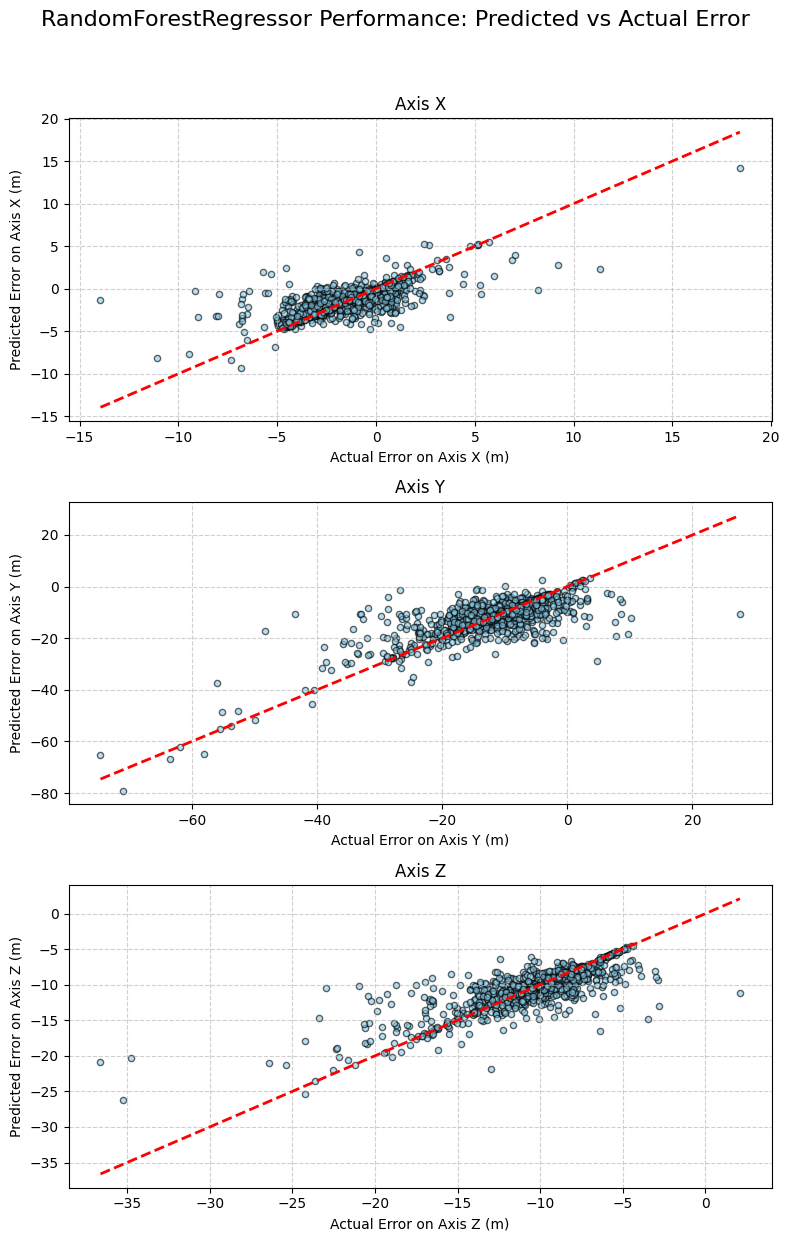

In [14]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

# --- 1. DATA LOADING AND UNIFICATION ---

def load_and_unify_data(spp_filepath, kinematic_filepath):
    """
    Loads SPP and Kinematic data, aligns them, calculates differences,
    and returns a single unified DataFrame using explicit column names.
    """
    try:
        spp_df = pd.read_csv(spp_filepath)
        kin_df = pd.read_csv(kinematic_filepath)
        print(f"✓ SPP file loaded with {len(spp_df)} rows.")
        print(f"✓ Kinematic file loaded with {len(kin_df)} rows.")
    except Exception as e:
        print(f"✗ Error loading files: {e}")
        return None, None, None, None, None

    spp_df['GPST'] = pd.to_datetime(spp_df['GPST']).dt.floor('S')
    kin_df['GPST'] = pd.to_datetime(kin_df['GPST']).dt.floor('S')

    c = pd.merge(spp_df, kin_df, how='inner', on='GPST')

    unified_df = c.copy()

    unified_df['diff_x'] = unified_df['x_y'] - unified_df['x_x']
    unified_df['diff_y'] = unified_df['y_y'] - unified_df['y_x']
    unified_df['diff_z'] = unified_df['z_y'] - unified_df['z_x']

    feature_cols = ['x_x', 'y_x', 'z_x', 'ns', 'sdx(m)', 'sdy(m)', 'sdz(m)']

    return unified_df, feature_cols, 'x_x', 'y_x', 'z_x'


# --- 2. MODEL TRAINING AND EVALUATION ---

def train_and_evaluate(unified_df, feature_cols):
    """Splits data, trains and tunes models, and returns the best model, scaler, and predictions."""
    X = unified_df[feature_cols]
    y = unified_df[['diff_x', 'diff_y', 'diff_z']]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- Model Tuning ---
    models = {
        'RandomForest': (RandomForestRegressor(random_state=42), {
            'n_estimators': [100, 200],
            'max_depth': [10, 20],
            'min_samples_leaf': [2, 4]
        }),
        'XGBoost': (XGBRegressor(random_state=42), {
            'n_estimators': [100, 200],
            'max_depth': [5, 7],
            'learning_rate': [0.05, 0.1]
        })
    }

    best_model = None
    best_score = -np.inf
    print("\n" + "="*80 + "\nHYPERPARAMETER TUNING AND MODEL SELECTION\n" + "="*80)

    for name, (model, params) in models.items():
        print(f"\nTuning {name}...")
        grid_search = GridSearchCV(model, params, cv=3, scoring='r2', n_jobs=-1, verbose=1)
        grid_search.fit(X_train_scaled, y_train.values)
        print(f"  Best R² score for {name}: {grid_search.best_score_:.4f}")
        if grid_search.best_score_ > best_score:
            best_score = grid_search.best_score_
            best_model = grid_search.best_estimator_
            print(f"  *** New best model found: {name} with params {grid_search.best_params_} ***")

    # --- Final Evaluation ---
    y_pred = best_model.predict(X_test_scaled)
    y_test_vals = y_test.values
    model_name = best_model.__class__.__name__

    print("\n" + "="*80 + f"\nFINAL EVALUATION: {model_name.upper()}\n" + "="*80)
    per_axis_rmse = []
    for i, axis in enumerate(['X', 'Y', 'Z']):
        rmse = np.sqrt(mean_squared_error(y_test_vals[:, i], y_pred[:, i]))
        per_axis_rmse.append(rmse)
        print(f"--- Axis {axis} ---\n  Test R² Score: {r2_score(y_test_vals[:, i], y_pred[:, i]):.4f}\n  RMSE (m): {rmse:.4f}\n")

    overall_rmse = np.sqrt(np.sum(np.square(per_axis_rmse)))
    print(f"--- Overall 3D Error ---\n  Euclidean RMSE (m): {overall_rmse:.4f}\n")

    plot_results(y_test_vals, y_pred, model_name)

    return best_model, scaler, X_test, y_pred


# --- 3. ACCURACY IMPROVEMENT ANALYSIS ---

def calculate_accuracy_improvement(test_df, y_pred_corrected, spp_cols):
    """Calculates and prints the before-and-after 3D error comparison."""
    spp_x_col, spp_y_col, spp_z_col = spp_cols

    # Original 3D Error
    original_3d_errors = np.sqrt(test_df['diff_x']**2 + test_df['diff_y']**2 + test_df['diff_z']**2)
    mean_original_error = original_3d_errors.mean()

    # Corrected 3D Error
    corrected_spp_x = test_df[spp_x_col] + y_pred_corrected[:, 0]
    corrected_spp_y = test_df[spp_y_col] + y_pred_corrected[:, 1]
    corrected_spp_z = test_df[spp_z_col] + y_pred_corrected[:, 2]

    corrected_diff_x = test_df['x_y'] - corrected_spp_x
    corrected_diff_y = test_df['y_y'] - corrected_spp_y
    corrected_diff_z = test_df['z_y'] - corrected_spp_z

    corrected_3d_errors = np.sqrt(corrected_diff_x**2 + corrected_diff_y**2 + corrected_diff_z**2)
    mean_corrected_error = corrected_3d_errors.mean()

    improvement = mean_original_error - mean_corrected_error
    improvement_percent = (improvement / mean_original_error) * 100 if mean_original_error != 0 else 0

    print("\n" + "="*80 + "\nMODEL ACCURACY IMPROVEMENT ANALYSIS\n" + "="*80)
    print(f"Mean 3D Error (Original): {mean_original_error:.4f} m")
    print(f"Mean 3D Error (Corrected): {mean_corrected_error:.4f} m")
    print(f"\nImprovement: {improvement:.4f} m ({improvement_percent:.2f}%)")


# --- 4. VISUALIZATION ---

def plot_results(y_test, y_pred, model_name):
    """Generates and saves performance plots."""
    fig, axes = plt.subplots(3, 1, figsize=(8, 12), tight_layout=True)
    fig.suptitle(f'{model_name} Performance: Predicted vs Actual Error', fontsize=16, y=1.03)
    for i, label in enumerate(['X', 'Y', 'Z']):
        ax = axes[i]
        ax.scatter(y_test[:, i], y_pred[:, i], alpha=0.6, s=20, edgecolors='k', c='skyblue')
        ax.plot([y_test[:, i].min(), y_test[:, i].max()],
                [y_test[:, i].min(), y_test[:, i].max()], 'r--', lw=2)
        ax.set_xlabel(f'Actual Error on Axis {label} (m)')
        ax.set_ylabel(f'Predicted Error on Axis {label} (m)')
        ax.set_title(f'Axis {label}')
        ax.grid(True, linestyle='--', alpha=0.6)
    plt.savefig('model_performance_xyz.png', dpi=300)
    print("\n✓ Performance plots saved as 'model_performance_xyz.png'")


# --- 5. MAIN EXECUTION ---

def main():
    spp_filepath = '/content/extracted_coordinates_x.csv'
    kinematic_filepath = '/content/extracted_coordinates_y.csv'

    unified_df, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
    if unified_df is None:
        return

    best_model, scaler, X_test, y_pred = train_and_evaluate(unified_df, feature_cols)
    test_df = unified_df.loc[X_test.index]

    calculate_accuracy_improvement(test_df, y_pred, (spp_x, spp_y, spp_z))

    joblib.dump(best_model, 'best_gnss_model.joblib')
    joblib.dump(scaler, 'scaler.joblib')
    joblib.dump(feature_cols, 'feature_cols.joblib')
    print("\n✓ Best model, scaler, and feature list saved successfully!")
    print("\n✓ Analysis complete!")


if __name__ == "__main__":
    main()
